PHẦN 1: THỐNG KÊ MÔ TẢ & ĐẶC TRƯNG

1. Đọc dữ liệu

In [23]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
df = sns.load_dataset("iris") 

print(df.head())
print(df.shape)
print(df.dtypes)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


In [ ]:
# print(df.columns)
# for col in df.columns:
#     if df[col].dtype != 'object':
#         print(col)

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')
sepal_length
sepal_width
petal_length
petal_width


2. Tính các giá trị đặc trưng cho từng cột, mỗi cột là 1 feature

In [11]:
def tinhtoan(col):
    mean = col.mean()
    median = col.median()
    mode = col.mode()
    var = col.var()
    std = col.std()
    minium = col.min()
    maxium = col.max()
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1
    print(f' {col.name} :\n {float(mean), float(median), mode, float(var), float(std), float(minium), float(maxium), float(Q1), float(Q3), float(IQR)}') 
for col in df.columns:
    if df[col].dtype != 'object':
        tinhtoan(df[col])

 sepal_length :
 (5.843333333333334, 5.8, 0    5.0
Name: sepal_length, dtype: float64, 0.6856935123042507, 0.828066127977863, 4.3, 7.9, 5.1, 6.4, 1.3000000000000007)
 sepal_width :
 (3.0573333333333337, 3.0, 0    3.0
Name: sepal_width, dtype: float64, 0.189979418344519, 0.4358662849366982, 2.0, 4.4, 2.8, 3.3, 0.5)
 petal_length :
 (3.7580000000000005, 4.35, 0    1.4
1    1.5
Name: petal_length, dtype: float64, 3.116277852348993, 1.7652982332594662, 1.0, 6.9, 1.6, 5.1, 3.4999999999999996)
 petal_width :
 (1.1993333333333336, 1.3, 0    0.2
Name: petal_width, dtype: float64, 0.5810062639821029, 0.7622376689603465, 0.1, 2.5, 0.3, 1.8, 1.5)


3. Gom nhóm từng loài hoa bằng groupby rồi tính mean, std

In [21]:
df.groupby(["species"]).mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [22]:
df.groupby("species").std()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,0.352490,0.379064,0.173664,0.105386
versicolor,0.516171,0.313798,0.469911,0.197753
virginica,0.635880,0.322497,0.551895,0.274650


nhận xét : dựa vào bảng mean của từng biến số(feature), ta thấy nhóm hoa setosa khác biệt nhất 

PHẦN 2: PHÂN PHỐI XÁC SUẤT 

1. Vẽ histogram + KDE cho từng biên số 
+ Histogram (biểu đồ cột) thể hiện tần suất xuất hiện của dữ liệu(Biến rời rạc)
+ KDE (Kernel Density Estimation) là đường cong mượt biểu diễn ước lượng mật độ phân phối của dữ liệu( Biến liên tục) 

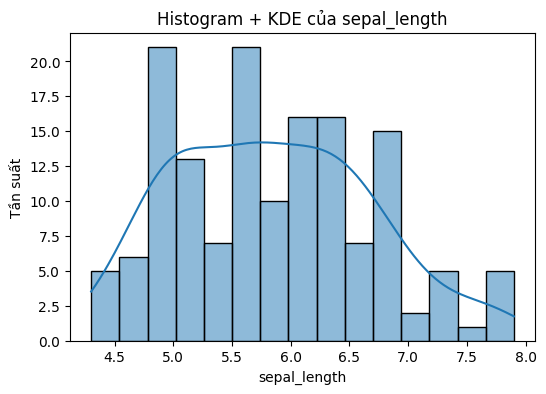

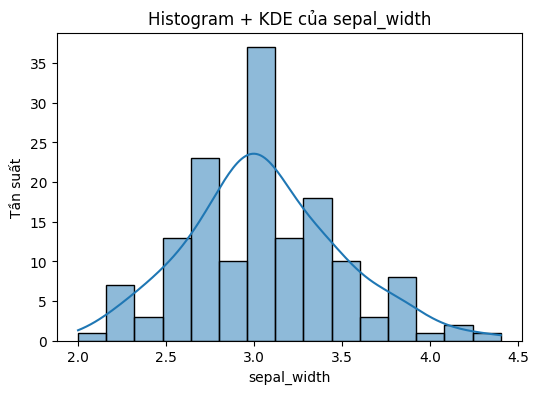

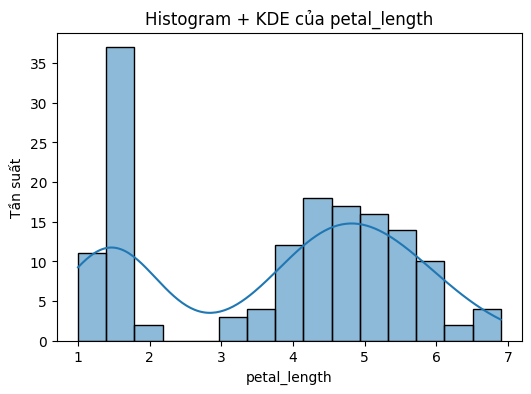

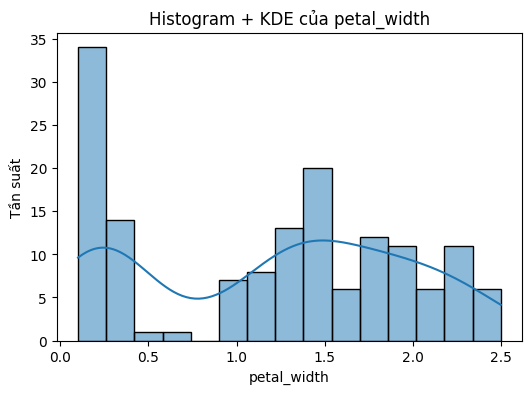

In [ ]:
for col in df.columns:
    if col != 'species':
        plt.figure(figsize=(6,4))
        sns.histplot(df[col], kde=True, bins=15) #kde=True :Seaborn sẽ tự vẽ thêm một đường cong KDE.
        plt.title(f"Histogram + KDE của {col}")
        plt.xlabel(col)
        plt.ylabel("Tần suất") # count
        plt.show()

Nhận xét : 
+ Sepal Length
Phân phối khá cân đối.
Gần giống phân phối chuẩn.
Có hơi lệch phải.
+ Sepal Width
Phân phối gần chuẩn.
Đỉnh tập trung quanh 3.0 cm.
Có một vài giá trị nhỏ và lớn nhưng không nhiều.
+ Petal Length
Không phải phân phối chuẩn.
Có nhiều đỉnh.

+ Petal Width
Tương tự Petal Length.
Có nhiều đỉnh.
Phân phối bị chia thành các cụm rõ rệt.

2. vẽ boxplot từng biến theo nhóm 
Boxplot (biểu đồ hộp) là biểu đồ dùng để mô tả sự phân bố của dữ liệu: 

+ Giá trị nhỏ nhất (Min)
+ Tứ phân vị thứ nhất (Q1)
+ Trung vị (Median)
+ Tứ phân vị thứ ba (Q3)
+ Giá trị lớn nhất (Max)
+ Các điểm ngoại lệ (Outlier) nếu có

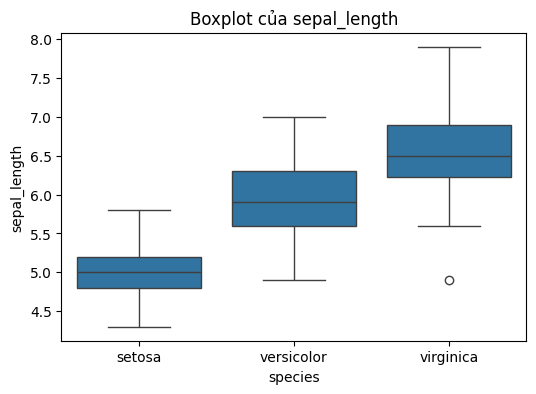

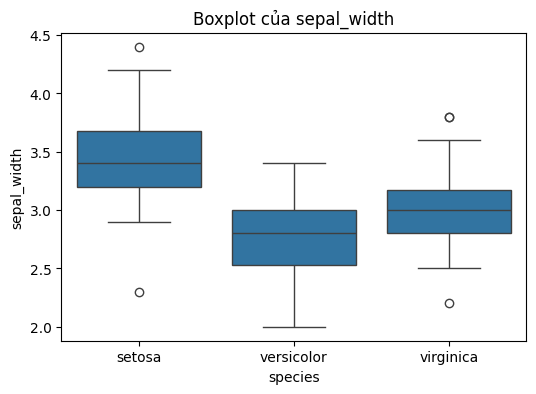

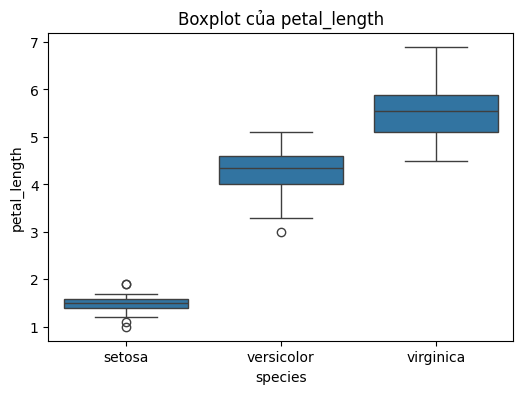

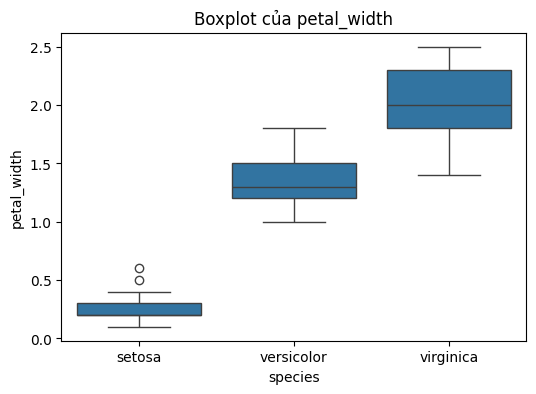

In [29]:
for col in df.columns:
    if col !="species":
        plt.figure(figsize=(6,4))
        sns.boxplot(
            x="species",
            y=col,
            data=df
        )
        plt.title(f"Boxplot của {col}")
        plt.show()

Chú thích : ví dụ của sepal_length
1. Setosa (hộp bên trái)
Q1: cạnh dưới của hộp ≈ 4.8
Median: đường ngang giữa hộp ≈ 5.0
Q3: cạnh trên của hộp ≈ 5.2
Min: đầu râu dưới ≈ 4.3
Max: đầu râu trên ≈ 5.8
2. Versicolor (hộp giữa)
Q1 ≈ 5.6
Median ≈ 5.9
Q3 ≈ 6.3
Min ≈ 4.9
Max ≈ 7.0
3. Virginica (hộp bên phải)
Q1 ≈ 6.2
Median ≈ 6.5
Q3 ≈ 6.9
Max ≈ 7.9
một chấm tròn ở khoảng 4.9 là outlier(nằm ngoài vùng (Q1-1,5IQR;Q3+1,5IQR)) 

3. Mô phỏng phân phối chuẩn

Chọn sepal_lenth

In [32]:
# tính mean, std
mean_sepal_lenth = df["sepal_length"].mean()
std_sepal_lenth = df["sepal_length"].std()

print(mean_sepal_lenth)
print(std_sepal_lenth)

5.843333333333334
0.828066127977863


In [46]:
#sinh dữ liệu bằng random
import numpy as np
np.random.seed(42)
data_sepal_lenth= np.random.normal(
    loc=mean_sepal_lenth,
    scale=std_sepal_lenth,
    size=len(df)
)
print(data_sepal_lenth)

[6.2546455  5.72884135 6.37966227 7.10450277 5.64943885 5.64945245
 7.15102597 6.47882004 5.4545775  6.29260893 5.45959284 5.4576783
 6.04369409 4.25901077 4.4149873  5.37772208 5.00464219 6.10355091
 5.09142935 4.67385248 7.05698743 5.65637563 5.89925115 4.66354762
 5.39254844 5.93518457 4.89023454 6.15443614 5.34596478 5.60179162
 5.34508047 7.37714216 5.83215674 4.96747874 6.52445491 4.83239406
 6.0162862  4.22059688 4.74350745 6.00634745 6.45483249 5.9852376
 5.74756891 5.59399956 4.61901935 5.24725473 5.46189397 6.71870044
 6.127872   4.3834195  6.11169629 5.52445974 5.28279715 6.34984175
 6.69706912 6.61449486 5.14840573 5.58728504 6.11764136 6.65114921
 5.44654538 5.68959542 4.92721482 4.85279515 6.51615844 6.96638976
 5.78370419 6.67432493 6.14279188 5.30913152 6.14259279 7.11692932
 5.813667   7.13896175 3.67401115 6.52392296 5.91541406 5.59573547
 5.91931732 4.19749484 5.66143048 6.13904616 7.06712733 5.41417132
 5.17384717 5.42784532 6.60134682 6.11556099 5.40465685 6.268352

sns.histplot() :vẽ histogram
Trục Y :
1. Density(mật độ)
stat="density" :Histogram sẽ được chuẩn hóa sao cho tổng diện tích = 1.
2. Count (Tần suất)
stat="count": Histogram biểu diễn số lượng mẫu trong mỗi khoảng

=> 
+ Histogram của dữ liệu thực.
+ Đường KDE (phân phối ước lượng từ dữ liệu).
+ Đường PDF của phân phối chuẩn lý thuyết.

Vẽ đường PDF lý thuyết và histogram thực tế

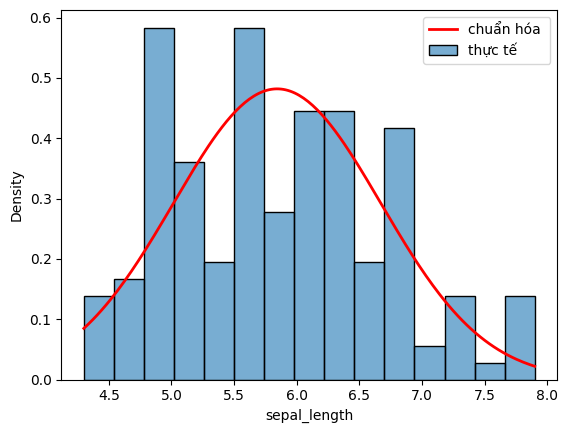

In [ ]:
from scipy.stats import norm

x = np.linspace(df["sepal_length"].min(),df["sepal_length"].max(),200) # 200 : số lượng điểm vẽ đường cong 
# chuẩn pdf
pdf = norm.pdf(x, mean_sepal_lenth, std_sepal_lenth)
# vẽ đường PDF lý thuyết
plt.plot(x,pdf,color="red",linewidth=2,label="chuẩn hóa ")
#Vẽ Histogram cho dữ liệu ban đầu(thực tế)

sns.histplot(df["sepal_length"],stat="density",bins=15,label="thực tế",alpha=0.6)
plt.title("")
plt.legend()
plt.show()

In [49]:
# # So sánh hai histogram
# plt.figure(figsize=(7,5))

# sns.histplot(df["sepal_length"],stat="density",bins=15,alpha=0.6,label="thực tế")

# sns.histplot(data_sepal_lenth,stat="density",bins=15,alpha=0.6,label="chuẩn hóa")

# plt.legend()
# plt.show()

Nhận xét : dữ liệu của biến Petal Length không tuân theo phân phối chuẩn khi xét toàn bộ tập Iris vì tập dữ liệu bao gồm ba loài hoa khác nhau. Mỗi loài có phân phối riêng và giá trị trung bình khác nhau, nên khi gộp lại tạo thành phân phối nhiều đỉnh . Do đó, đường phân phối chuẩn được sinh từ một giá trị mean và std chung không thể mô tả chính xác dữ liệu thực tế. Nếu phân tích riêng từng loài, phân phối của biến này sẽ gần với phân phối chuẩn hơn.

Hàm norm.pdf() của SciPy luôn tính PDF của phân phối chuẩn(Normal Distribution)
$$
f(x)=\frac{1}{\sigma\sqrt{2\pi}}
e^{-\frac{(x-\mu)^2}{2\sigma^2}}
$$
PDF: 
$$
X\sim N(\mu,\sigma^2)
$$
Giả sử sepal_length gồm ba loài:
$$
f(x)
=
w_1f_{\text{setosa}}(x)
+
w_2f_{\text{versicolor}}(x)
+
w_3f_{\text{virginica}}(x)
$$
với $$w_i$$ là tỷ lệ của mỗi loài (Iris có 50 mẫu mỗi loài nên wi=1/3).
=> 
$$
f(x)=
\frac{1}{3}N(\mu_1,\sigma_1^2)
+
\frac{1}{3}N(\mu_2,\sigma_2^2)
+
\frac{1}{3}N(\mu_3,\sigma_3^2)
$$

Đó gọi là Gaussian Mixture Distribution.
Hình dạng sẽ là :
      /\        /\          /\
     /  \______/  \________/  \

PHẦN 3: PHÂN TÍCH ĐA BIẾN & TƯƠNG QUAN

1. Tính ma trận hiệp phương sai(Covariance) và tương quan

In [ ]:

matrix_data= df.select_dtypes(include='number')

cov_matrix = matrix_data.cov()

print(cov_matrix)
# Hiệp phương sai dương cho thấy hai biến có xu hướng tăng cùng nhau.
# Hiệp phương sai âm cho thấy một biến tăng thì biến còn lại có xu hướng giảm.

              sepal_length  sepal_width  petal_length  petal_width
sepal_length      0.685694    -0.042434      1.274315     0.516271
sepal_width      -0.042434     0.189979     -0.329656    -0.121639
petal_length      1.274315    -0.329656      3.116278     1.295609
petal_width       0.516271    -0.121639      1.295609     0.581006


In [55]:
cor_matrix= matrix_data.corr()
print(cor_matrix)

              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


2. Vẽ heatmap tương quan

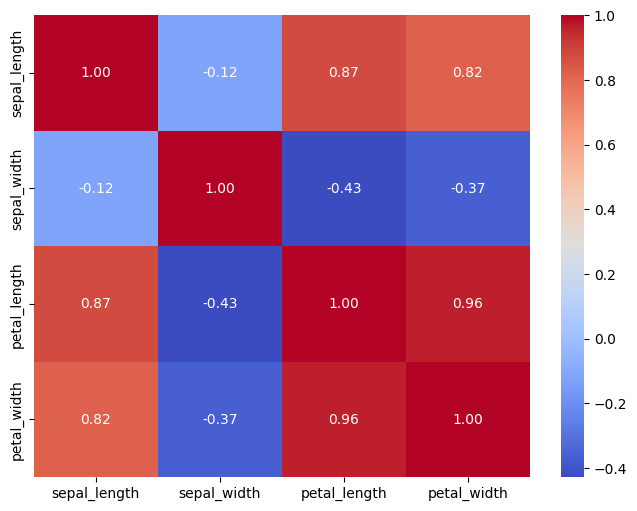

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(cor_matrix,annot=True,cmap="coolwarm",fmt=".2f"
)
plt.show()
#Giá trị càng gần 1 =>tương quan thuận mạnh.
#Giá trị càng gần -1 =>tương quan nghịch mạnh.
#Gần 0 => gần như không có tương quan tuyến tính.

Nhận xét :
Petal Length và Petal Width có hệ số tương quan khoảng 0.96, là cặp biến tương quan mạnh nhất.
- có dấu hiệu của cộng đa tuyến giữa Petal Length và Petal Width (0.96)

3. vẽ pairplot

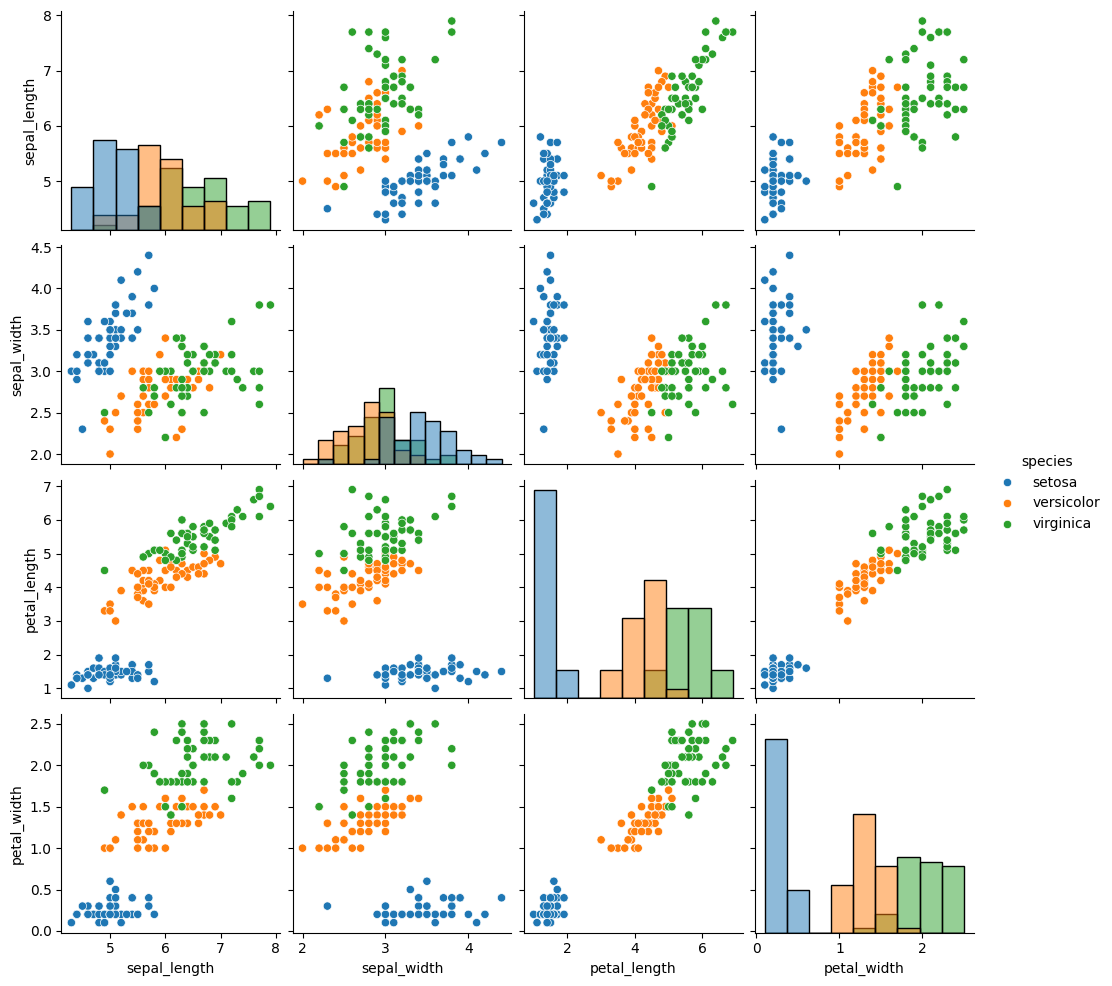

In [58]:
sns.pairplot(df,hue="species",diag_kind="hist")

plt.show()

Nhận xét :

Phần 4 — Xác suất & Định lý Bayes

In [62]:
P_B = 0.01
P_pos_given_B = 0.99
P_pos_given_notB = 0.05
def xacsuat(P_B,P_pos_given_B,P_pos_given_notB):
    P_pos = (P_pos_given_B * P_B + P_pos_given_notB * (1 - P_B))
    P_B_given_pos = (P_pos_given_B * P_B) / P_pos
    return P_B_given_pos

print(round(xacsuat(P_B,P_pos_given_B,P_pos_given_notB),4))

0.1667


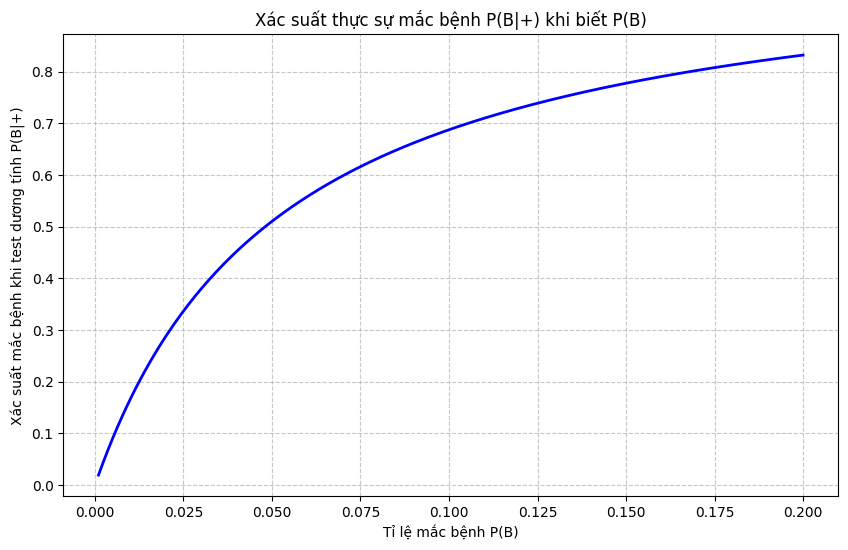

In [71]:
P_B_arr = np.linspace(0.001, 0.2, 300) # 300 điểm 
P_B_given_pos_arr =xacsuat(P_B_arr,P_pos_given_B,P_pos_given_notB)
# print(P_B_given_pos_arr)

#Vẽ đồ thị
plt.figure(figsize=(10, 6))
plt.plot(P_B_arr, P_B_given_pos_arr, color='blue', linewidth=2)
plt.title("Xác suất thực sự mắc bệnh P(B|+) khi biết P(B)")
plt.xlabel("Tỉ lệ mắc bệnh P(B)")
plt.ylabel("Xác suất mắc bệnh khi test dương tính P(B|+)")
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

BONUSS
